In [ ]:
!pip install opencv-contrib-python

Found existing installation: opencv-contrib-python 4.13.0.92
Uninstalling opencv-contrib-python-4.13.0.92:
  Successfully uninstalled opencv-contrib-python-4.13.0.92
  Obtaining dependency information for opencv-contrib-python from https://files.pythonhosted.org/packages/ba/f6/3c645c21358079097201090de7c30d110f5ec3fa01008e3ee81b0a77a354/opencv_contrib_python-4.13.0.92-cp37-abi3-manylinux_2_28_x86_64.whl.metadata
  Using cached opencv_contrib_python-4.13.0.92-cp37-abi3-manylinux_2_28_x86_64.whl.metadata (19 kB)
Using cached opencv_contrib_python-4.13.0.92-cp37-abi3-manylinux_2_28_x86_64.whl (79.2 MB)


In [2]:
!pip install ultralytics

In [1]:
import random
import time
import shutil
import xml.etree.ElementTree as ET
from pathlib import Path
from collections import Counter

import cv2
import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torchvision
from torchvision import transforms
from torchvision.ops import roi_pool

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {DEVICE}")

DATASET_ROOT = Path('fruit')
assert DATASET_ROOT.exists(), f"Dataset folder not found: {DATASET_ROOT.resolve()}"

CLASS_TO_ID = {'apple': 0, 'banana': 1, 'orange': 2}
ID_TO_CLASS = {v: k for k, v in CLASS_TO_ID.items()}
VALID_IMAGE_EXTS = {'.jpg', '.jpeg', '.png'}

plt.rcParams['figure.figsize'] = (11, 7)

Using device: cuda


In [2]:
def parse_voc_xml(xml_path: Path):
    tree = ET.parse(xml_path)
    root = tree.getroot()

    width = int(root.find('size/width').text)
    height = int(root.find('size/height').text)

    labels, boxes = [], []
    for obj in root.findall('object'):
        label = obj.findtext('name', default='').strip().lower()
        bnd = obj.find('bndbox')
        xmin = int(float(bnd.findtext('xmin', default='0')))
        ymin = int(float(bnd.findtext('ymin', default='0')))
        xmax = int(float(bnd.findtext('xmax', default='0')))
        ymax = int(float(bnd.findtext('ymax', default='0')))
        labels.append(label)
        boxes.append([xmin, ymin, xmax, ymax])

    return {'width': width, 'height': height, 'labels': labels, 'boxes': boxes}


def resolve_image_for_xml(xml_path: Path):
    for ext in VALID_IMAGE_EXTS:
        candidate = xml_path.with_suffix(ext)
        if candidate.exists():
            return candidate
    return None


def build_dataset_index(root_dir: Path):
    xml_files = sorted(root_dir.glob('*.xml'))
    pairs = []
    missing = []
    counts = Counter()

    for xml_path in xml_files:
        image_path = resolve_image_for_xml(xml_path)
        if image_path is None:
            missing.append(xml_path)
            continue

        ann = parse_voc_xml(xml_path)
        for lbl in ann['labels']:
            if lbl in CLASS_TO_ID:
                counts[lbl] += 1

        pairs.append({'xml_path': xml_path, 'image_path': image_path, 'annotation': ann})

    return pairs, missing, counts


def draw_boxes_cv2(image_bgr, boxes, labels=None, color=(0, 255, 0), thickness=2):
    output = image_bgr.copy()
    labels = labels if labels is not None else ['obj'] * len(boxes)

    for box, label in zip(boxes, labels):
        x1, y1, x2, y2 = [int(v) for v in box]
        cv2.rectangle(output, (x1, y1), (x2, y2), color, thickness)
        cv2.putText(
            output,
            str(label),
            (x1, max(15, y1 - 6)),
            cv2.FONT_HERSHEY_SIMPLEX,
            0.6,
            color,
            2,
            cv2.LINE_AA,
        )
    return output


def show_image_bgr(image_bgr, title='Image'):
    rgb = cv2.cvtColor(image_bgr, cv2.COLOR_BGR2RGB)
    plt.figure()
    plt.imshow(rgb)
    plt.title(title)
    plt.axis('off')
    plt.show()

In [3]:
pairs, missing_images, class_counter = build_dataset_index(DATASET_ROOT)

print(f"Total XML annotations: {len(list(DATASET_ROOT.glob('*.xml')))}")
print(f"Valid image-annotation pairs: {len(pairs)}")
print(f"Missing image files: {len(missing_images)}")
print('Object counts by class:', dict(class_counter))

assert len(pairs) > 0, 'No valid image/XML pairs found.'

Total XML annotations: 60
Valid image-annotation pairs: 60
Missing image files: 0
Object counts by class: {'apple': 35, 'banana': 40, 'orange': 42}


## Preparation: Ground Truth Visualization

Random image: fruit/mixed_24.jpg
Ground-truth objects: [('apple', [113, 36, 276, 182]), ('banana', [280, 83, 452, 255]), ('banana', [188, 77, 412, 217]), ('banana', [172, 78, 395, 176])]


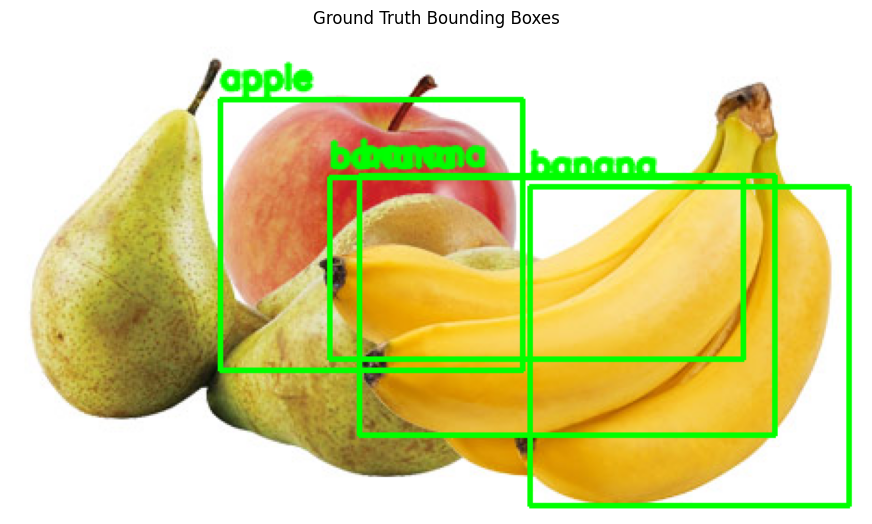

In [4]:
sample_item = random.choice(pairs)
img_path = sample_item['image_path']
ann = sample_item['annotation']

print('Random image:', img_path)
print('Ground-truth objects:', list(zip(ann['labels'], ann['boxes'])))

image_bgr = cv2.imread(str(img_path))
assert image_bgr is not None, f'Failed to read image: {img_path}'

viz_gt = draw_boxes_cv2(image_bgr, ann['boxes'], ann['labels'], color=(0, 255, 0), thickness=2)
show_image_bgr(viz_gt, 'Ground Truth Bounding Boxes')

## Task 1 - Intersection over Union (IoU)

In [5]:
def iou_xyxy(box_a, box_b):
    ax1, ay1, ax2, ay2 = [float(v) for v in box_a]
    bx1, by1, bx2, by2 = [float(v) for v in box_b]

    inter_x1 = max(ax1, bx1)
    inter_y1 = max(ay1, by1)
    inter_x2 = min(ax2, bx2)
    inter_y2 = min(ay2, by2)

    inter_w = max(0.0, inter_x2 - inter_x1)
    inter_h = max(0.0, inter_y2 - inter_y1)
    inter_area = inter_w * inter_h

    area_a = max(0.0, ax2 - ax1) * max(0.0, ay2 - ay1)
    area_b = max(0.0, bx2 - bx1) * max(0.0, by2 - by1)
    union = area_a + area_b - inter_area

    if union <= 0.0:
        return 0.0
    return inter_area / union


hardcoded_pairs = [
    ([20, 20, 120, 120], [25, 25, 115, 115], 'Highly overlapping'),
    ([10, 10, 100, 100], [60, 60, 160, 160], 'Partially overlapping'),
    ([0, 0, 50, 50], [90, 90, 150, 150], 'Completely disjoint'),
]

for box1, box2, desc in hardcoded_pairs:
    print(f"{desc:22s} -> IoU: {iou_xyxy(box1, box2):.4f}")

Highly overlapping     -> IoU: 0.8100
Partially overlapping  -> IoU: 0.0970
Completely disjoint    -> IoU: 0.0000


## Task 2 - The Baseline: Selective Search (R-CNN Step 1)

In [ ]:
!pip install opencv-contrib-python

Selective Search image: fruit/apple_84.jpg
Proposals returned: 200


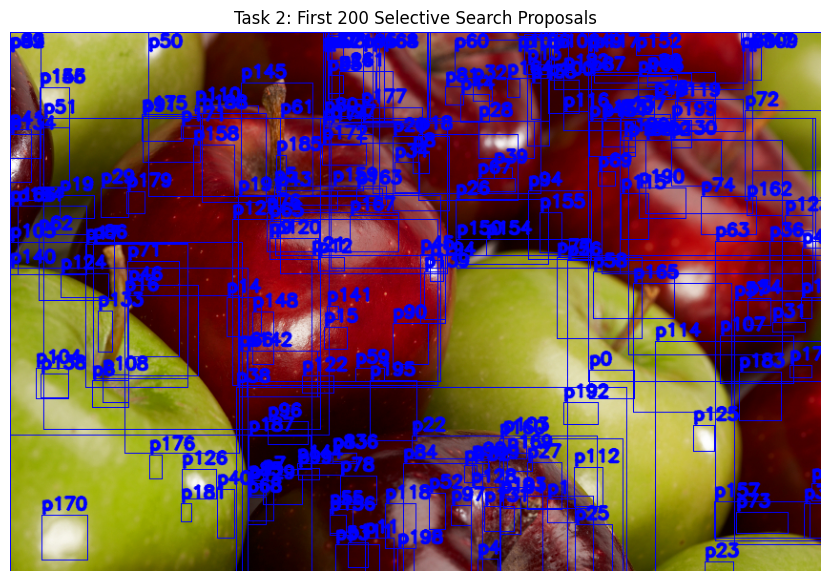

In [7]:
def run_selective_search(image_bgr, max_props=200):
    if not hasattr(cv2, 'ximgproc') or not hasattr(cv2.ximgproc, 'segmentation'):
        raise RuntimeError('Selective Search unavailable. Install opencv-contrib-python.')

    ss = cv2.ximgproc.segmentation.createSelectiveSearchSegmentation()
    ss.setBaseImage(image_bgr)
    ss.switchToSelectiveSearchFast()
    rects = ss.process()  # [x, y, w, h]

    proposals = []
    for x, y, w, h in rects[:max_props]:
        proposals.append([int(x), int(y), int(x + w), int(y + h)])
    return proposals


ss_item = random.choice(pairs)
ss_img_path = ss_item['image_path']
ss_image_bgr = cv2.imread(str(ss_img_path))
assert ss_image_bgr is not None, f'Unable to read image: {ss_img_path}'

proposals_200 = run_selective_search(ss_image_bgr, max_props=200)
print('Selective Search image:', ss_img_path)
print('Proposals returned:', len(proposals_200))

ss_vis = draw_boxes_cv2(
    ss_image_bgr,
    proposals_200,
    labels=[f'p{i}' for i in range(len(proposals_200))],
    color=(255, 0, 0),
    thickness=1,
)
show_image_bgr(ss_vis, 'Task 2: First 200 Selective Search Proposals')

## Task 3 - R-CNN Bottleneck Simulation (Per-Proposal CNN Pass)

In [8]:
resnet18 = torchvision.models.resnet18(
    weights=torchvision.models.ResNet18_Weights.IMAGENET1K_V1
).to(DEVICE)
resnet18.eval()

# Remove final FC classification layer and output 512-d feature vectors.
feature_extractor_rcnn = nn.Sequential(*list(resnet18.children())[:-1]).to(DEVICE)
feature_extractor_rcnn.eval()

crop_transform = transforms.Compose([
    transforms.ToPILImage(),
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

h, w = ss_image_bgr.shape[:2]
proposals_100 = proposals_200[:100]

rcnn_features = []
start_t = time.time()
with torch.no_grad():
    for box in proposals_100:
        x1, y1, x2, y2 = box
        x1 = max(0, min(x1, w - 1))
        y1 = max(0, min(y1, h - 1))
        x2 = max(1, min(x2, w))
        y2 = max(1, min(y2, h))

        if x2 <= x1 or y2 <= y1:
            continue

        crop_bgr = ss_image_bgr[y1:y2, x1:x2]
        crop_rgb = cv2.cvtColor(crop_bgr, cv2.COLOR_BGR2RGB)
        inp = crop_transform(crop_rgb).unsqueeze(0).to(DEVICE)
        feat = feature_extractor_rcnn(inp).flatten(1)
        rcnn_features.append(feat.cpu())

task3_time = time.time() - start_t
print(f'Task 3: Processed {len(rcnn_features)} / {len(proposals_100)} crops')
print(f'Task 3 total execution time (100 crops): {task3_time:.4f} seconds')

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /home/devarsh/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth
100.0%


Task 3: Processed 100 / 100 crops
Task 3 total execution time (100 crops): 0.7261 seconds


## Task 4 - Fast R-CNN (Single Feature Map + RoI Pooling)

In [ ]:
backbone_conv = nn.Sequential(*list(resnet18.children())[:-2]).to(DEVICE)
backbone_conv.eval()

img_rgb = cv2.cvtColor(ss_image_bgr, cv2.COLOR_BGR2RGB)
img_tensor = torch.from_numpy(img_rgb).permute(2, 0, 1).float() / 255.0
img_norm = transforms.Normalize(
    mean=[0.485, 0.456, 0.406],
    std=[0.229, 0.224, 0.225],
)(img_tensor).unsqueeze(0).to(DEVICE)

start_t = time.time()
with torch.no_grad():
    feature_map = backbone_conv(img_norm)

    img_h, img_w = ss_image_bgr.shape[:2]
    feat_h, feat_w = feature_map.shape[-2:]
    spatial_scale_h = feat_h / img_h
    spatial_scale_w = feat_w / img_w
    spatial_scale = float((spatial_scale_h + spatial_scale_w) / 2.0)

    boxes_100_tensor = torch.tensor(proposals_100, dtype=torch.float32, device=DEVICE)
    pooled = roi_pool(
        feature_map,
        [boxes_100_tensor],
        output_size=(7, 7),
        spatial_scale=spatial_scale,
    )

task4_time = time.time() - start_t
speedup = task3_time / max(task4_time, 1e-8)

print(f'Feature map shape: {tuple(feature_map.shape)}')
print(f'Spatial scale used: {spatial_scale:.6f}')
print(f'RoI pooled tensor shape: {tuple(pooled.shape)}')
print(f'Task 4 total execution time (1 CNN pass + RoI pool): {task4_time:.4f} seconds')
print(f'Speedup vs Task 3: {speedup:.2f}x')

Feature map shape: (1, 512, 18, 27)
Spatial scale used: 0.031812
RoI pooled tensor shape: (100, 512, 7, 7)
Task 4 total execution time (1 CNN pass + RoI pool): 0.0705 seconds
Speedup vs Task 3: 10.30x


### Conceptual Analysis (Task 4)
Fast R-CNN removes repeated convolutional computation. In R-CNN, each proposal is cropped and passed through deep convolution layers independently, so overlapping regions trigger almost identical convolutions many times. Fast R-CNN computes the convolutional feature map only once for the whole image, then uses RoI pooling to slice proposal-specific features directly from that shared map. This eliminates redundant convolution operations and drastically reduces total inference time.

## Task 5 - Faster R-CNN Inference + Confidence Filtering

Downloading: "https://download.pytorch.org/models/fasterrcnn_resnet50_fpn_coco-258fb6c6.pth" to /home/devarsh/.cache/torch/hub/checkpoints/fasterrcnn_resnet50_fpn_coco-258fb6c6.pth
100.0%


Total predictions: 31
Filtered predictions (score >= 0.80): 10


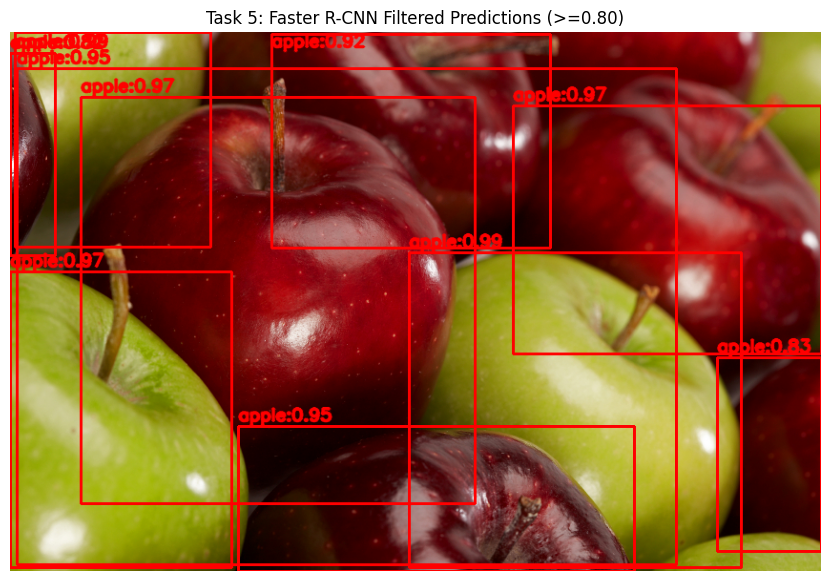

In [10]:
faster_rcnn = torchvision.models.detection.fasterrcnn_resnet50_fpn(
    weights=torchvision.models.detection.FasterRCNN_ResNet50_FPN_Weights.DEFAULT
).to(DEVICE)
faster_rcnn.eval()

coco_names = torchvision.models.detection.FasterRCNN_ResNet50_FPN_Weights.DEFAULT.meta['categories']


def filter_by_confidence(pred, threshold=0.80):
    scores = pred['scores'].detach().cpu().numpy()
    keep = np.where(scores >= threshold)[0]

    boxes = pred['boxes'].detach().cpu().numpy()[keep].tolist()
    labels = pred['labels'].detach().cpu().numpy()[keep].tolist()
    confs = pred['scores'].detach().cpu().numpy()[keep].tolist()
    return boxes, labels, confs


det_input = torch.from_numpy(img_rgb).permute(2, 0, 1).float() / 255.0
with torch.no_grad():
    prediction = faster_rcnn([det_input.to(DEVICE)])[0]

f_boxes, f_labels, f_scores = filter_by_confidence(prediction, threshold=0.80)
print(f'Total predictions: {len(prediction["boxes"])}')
print(f'Filtered predictions (score >= 0.80): {len(f_boxes)}')

f_label_names = [f"{coco_names[l]}:{s:.2f}" for l, s in zip(f_labels, f_scores)]
f_viz = draw_boxes_cv2(ss_image_bgr, f_boxes, f_label_names, color=(0, 0, 255), thickness=2)
show_image_bgr(f_viz, 'Task 5: Faster R-CNN Filtered Predictions (>=0.80)')

### Conceptual Analysis (Task 5)
The Region Proposal Network (RPN) is integrated inside Faster R-CNN and shares convolutional features with the detector. Instead of running an external hand-crafted proposal algorithm (like Selective Search) on the raw image, the RPN directly predicts object-like regions from the feature map. This makes proposal generation trainable, faster, and end-to-end with the detection network.

## Task 6 - Custom Non-Maximum Suppression (NMS)

Raw predictions: 31
After custom NMS (all scores): 29
After custom NMS + confidence >= 0.80: 10


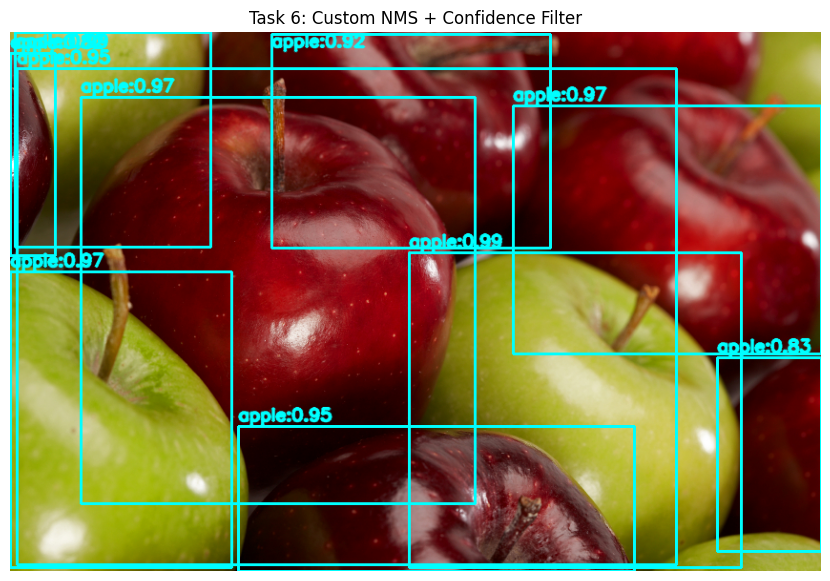

In [11]:
def custom_nms(boxes, scores, iou_threshold=0.5):
    if len(boxes) == 0:
        return []

    idxs = np.argsort(np.array(scores))[::-1].tolist()
    keep = []

    while idxs:
        current = idxs.pop(0)
        keep.append(current)

        remaining = []
        for idx in idxs:
            if iou_xyxy(boxes[current], boxes[idx]) <= iou_threshold:
                remaining.append(idx)
        idxs = remaining

    return keep


raw_boxes = prediction['boxes'].detach().cpu().numpy().tolist()
raw_scores = prediction['scores'].detach().cpu().numpy().tolist()
raw_labels = prediction['labels'].detach().cpu().numpy().tolist()

keep_idx = custom_nms(raw_boxes, raw_scores, iou_threshold=0.5)

nms_boxes = [raw_boxes[i] for i in keep_idx if raw_scores[i] >= 0.80]
nms_scores = [raw_scores[i] for i in keep_idx if raw_scores[i] >= 0.80]
nms_labels = [raw_labels[i] for i in keep_idx if raw_scores[i] >= 0.80]

print(f'Raw predictions: {len(raw_boxes)}')
print(f'After custom NMS (all scores): {len(keep_idx)}')
print(f'After custom NMS + confidence >= 0.80: {len(nms_boxes)}')

nms_label_names = [f"{coco_names[l]}:{s:.2f}" for l, s in zip(nms_labels, nms_scores)]
nms_viz = draw_boxes_cv2(ss_image_bgr, nms_boxes, nms_label_names, color=(255, 255, 0), thickness=2)
show_image_bgr(nms_viz, 'Task 6: Custom NMS + Confidence Filter')

### Conceptual Analysis (Task 6)
With a very high IoU threshold (0.9), suppression is weak, so many highly overlapping boxes remain. In crowded fruit clusters, this can keep duplicate detections around the same object and make the output cluttered. With a very low IoU threshold (0.1), suppression is aggressive, so nearby boxes are removed quickly; this reduces duplicates but can wrongly suppress true neighboring objects that are close together. For tightly packed objects, an intermediate threshold (for example 0.4 to 0.6) is usually more balanced.

## Task 7 - YOLOv8 Fine-Tuning

In [14]:
from ultralytics import YOLO

YOLO_ROOT = Path('yolo_fruit')
IMAGES_DIR = YOLO_ROOT / 'images'
LABELS_DIR = YOLO_ROOT / 'labels'
for split in ['train', 'val', 'test']:
    (IMAGES_DIR / split).mkdir(parents=True, exist_ok=True)
    (LABELS_DIR / split).mkdir(parents=True, exist_ok=True)


def xyxy_to_yolo(box, img_w, img_h):
    x1, y1, x2, y2 = box
    bw = max(0.0, x2 - x1)
    bh = max(0.0, y2 - y1)
    cx = x1 + bw / 2.0
    cy = y1 + bh / 2.0
    return [cx / img_w, cy / img_h, bw / img_w, bh / img_h]


shuffled_pairs = pairs.copy()
random.shuffle(shuffled_pairs)
n = len(shuffled_pairs)
n_train = int(0.7 * n)
n_val = int(0.15 * n)

split_dict = {
    'train': shuffled_pairs[:n_train],
    'val': shuffled_pairs[n_train:n_train + n_val],
    'test': shuffled_pairs[n_train + n_val:],
}

for split_name, items in split_dict.items():
    for item in items:
        img_src = item['image_path']
        xml_ann = item['annotation']

        if xml_ann['width'] <= 0 or xml_ann['height'] <= 0:
            continue

        img_dst = IMAGES_DIR / split_name / img_src.name
        shutil.copy2(img_src, img_dst)

        label_path = (LABELS_DIR / split_name / img_src.stem).with_suffix('.txt')
        lines = []
        for label, box in zip(xml_ann['labels'], xml_ann['boxes']):
            if label not in CLASS_TO_ID:
                continue
            cls_id = CLASS_TO_ID[label]
            x, y, w, h = xyxy_to_yolo(box, xml_ann['width'], xml_ann['height'])
            lines.append(f"{cls_id} {x:.6f} {y:.6f} {w:.6f} {h:.6f}")

        label_path.write_text('\n'.join(lines) + ('\n' if lines else ''))


data_yaml = YOLO_ROOT / 'fruit.yaml'
data_yaml.write_text(
    '\n'.join([
        f"path: {YOLO_ROOT.resolve()}",
        'train: images/train',
        'val: images/val',
        'test: images/test',
        "names:",
        "  0: apple",
        "  1: banana",
        "  2: orange",
    ]) + '\n'
)

print('YOLO dataset prepared at:', YOLO_ROOT.resolve())
print('YAML:', data_yaml.resolve())
print('Split sizes:', {k: len(v) for k, v in split_dict.items()})

YOLO dataset prepared at: /home/devarsh/Work/deeplearning/yolo_fruit
YAML: /home/devarsh/Work/deeplearning/yolo_fruit/fruit.yaml
Split sizes: {'train': 42, 'val': 9, 'test': 9}


In [15]:
yolo_finetune = YOLO('yolov8n.pt')

yolo_train_results = yolo_finetune.train(
    data=str(data_yaml),
    epochs=10,
    imgsz=640,
    batch=16 if torch.cuda.is_available() else 4,
    device=0 if torch.cuda.is_available() else 'cpu',
    project='yolo_runs',
    name='fruit_yolov8n_finetune',
    seed=SEED,
)

Ultralytics 8.4.33 🚀 Python-3.12.0 torch-2.6.0+cu124 CUDA:0 (NVIDIA GeForce RTX 3050 Laptop GPU, 3770MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=yolo_fruit/fruit.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=10, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=fruit_yolov8n_finetune, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=Tr

In [19]:
# Evaluate fine-tuned model and report mAP metrics.
best_weights = Path('runs/detect/yolo_runs/fruit_yolov8n_finetune/weights/best.pt')
if not best_weights.exists():
    print('Best weights not found yet. Run training cell first.')
else:
    yolo_tuned = YOLO(str(best_weights))
    tuned_metrics = yolo_tuned.val(data=str(data_yaml), split='test')

    print(f"Fine-tuned YOLO mAP@50: {tuned_metrics.box.map50:.4f}")
    print(f"Fine-tuned YOLO mAP@50-95: {tuned_metrics.box.map:.4f}")
    print(f"Fine-tuned YOLO precision: {tuned_metrics.box.mp:.4f}")
    print(f"Fine-tuned YOLO recall: {tuned_metrics.box.mr:.4f}")

Ultralytics 8.4.33 🚀 Python-3.12.0 torch-2.6.0+cu124 CUDA:0 (NVIDIA GeForce RTX 3050 Laptop GPU, 3770MiB)
Model summary (fused): 73 layers, 3,006,233 parameters, 0 gradients, 8.1 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 168.3±116.5 MB/s, size: 118.5 KB)
val: Scanning /home/devarsh/Work/deeplearning/yolo_fruit/labels/test.cache... 8 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 8/8 30.5Kit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 1/1 8.3s/it 8.3s
                   all          8         12    0.00513          1      0.606      0.456
                 apple          4          7     0.0101          1       0.93        0.8
                banana          1          1    0.00176          1      0.497      0.328
                orange          3          4    0.00351          1       0.39       0.24
Speed: 205.3ms preprocess, 372.0ms inference, 0.0ms loss, 22.5ms postprocess per image
Results sav

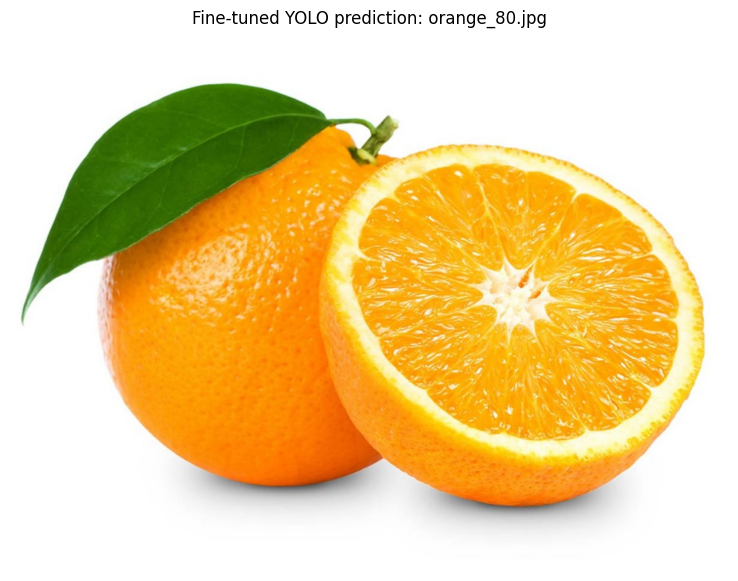

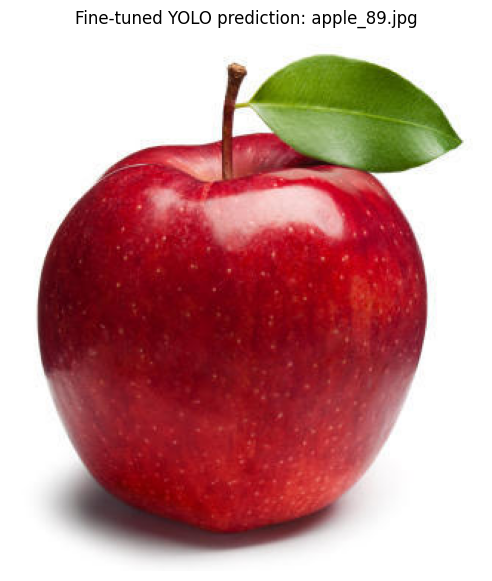

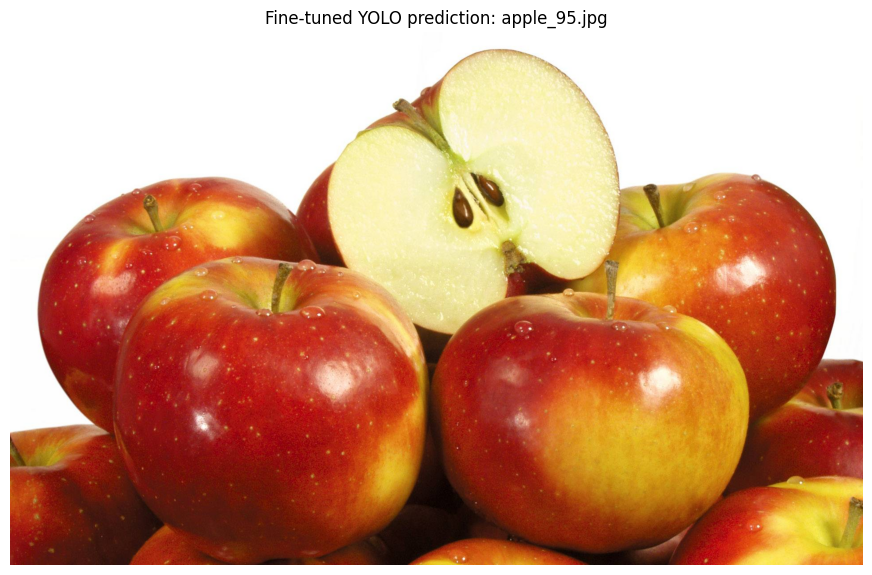

In [ ]:
test_images = sorted((IMAGES_DIR / 'test').glob('*'))
if not best_weights.exists() or len(test_images) == 0:
    print('Need trained weights and non-empty test split before running this cell.')
else:
    yolo_tuned = YOLO(str(best_weights))
    sample_test_images = random.sample(test_images, k=min(3, len(test_images)))

    for p in sample_test_images:
        results = yolo_tuned.predict(source=str(p), conf=0.25, verbose=False)
        pred_bgr = results[0].plot()
        show_image_bgr(pred_bgr, title=f'Fine-tuned YOLO prediction: {p.name}')

## Model Comparison (Faster R-CNN vs YOLO Pretrained vs YOLO Fine-Tuned)

In [22]:
def compute_fasterrcnn_metrics_on_test(test_items, conf_thr=0.80, iou_thr=0.5):
    tp = 0
    fp = 0
    fn = 0

    label_map = {'banana': 47, 'apple': 53, 'orange': 55}  

    times = []
    for item in test_items:
        img_bgr = cv2.imread(str(item['image_path']))
        img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
        det_in = torch.from_numpy(img_rgb).permute(2, 0, 1).float() / 255.0

        t0 = time.time()
        with torch.no_grad():
            pred = faster_rcnn([det_in.to(DEVICE)])[0]
        times.append((time.time() - t0) * 1000.0)

        pred_boxes = pred['boxes'].detach().cpu().numpy().tolist()
        pred_labels = pred['labels'].detach().cpu().numpy().tolist()
        pred_scores = pred['scores'].detach().cpu().numpy().tolist()

        gt_boxes = item['annotation']['boxes']
        gt_labels = item['annotation']['labels']

        used_gt = set()
        for pb, pl, ps in zip(pred_boxes, pred_labels, pred_scores):
            if ps < conf_thr:
                continue

            matched = False
            for gi, (gb, gl) in enumerate(zip(gt_boxes, gt_labels)):
                if gi in used_gt:
                    continue
                if gl not in label_map:
                    continue
                if pl != label_map[gl]:
                    continue
                if iou_xyxy(pb, gb) >= iou_thr:
                    tp += 1
                    used_gt.add(gi)
                    matched = True
                    break

            if not matched:
                fp += 1

        fn += (len(gt_boxes) - len(used_gt))

    precision = tp / (tp + fp) if (tp + fp) > 0 else 0.0
    recall = tp / (tp + fn) if (tp + fn) > 0 else 0.0
    avg_ms = float(np.mean(times)) if len(times) > 0 else 0.0
    return precision, recall, avg_ms


def compute_yolo_avg_inference_ms(model, image_paths):
    times = []
    for p in image_paths:
        t0 = time.time()
        _ = model.predict(source=str(p), conf=0.25, verbose=False)
        times.append((time.time() - t0) * 1000.0)
    return float(np.mean(times)) if times else 0.0


test_items = split_dict['test']
test_paths = [x['image_path'] for x in test_items]

# Faster R-CNN metrics
frcnn_precision, frcnn_recall, frcnn_ms = compute_fasterrcnn_metrics_on_test(test_items)

# YOLO pretrained metrics
yolo_pretrained = YOLO('yolov8n.pt')
yolo_pre_metrics = yolo_pretrained.val(data=str(data_yaml), split='test')
yolo_pre_ms = compute_yolo_avg_inference_ms(yolo_pretrained, test_paths)

# YOLO fine-tuned metrics
if best_weights.exists():
    yolo_tuned = YOLO(str(best_weights))
    yolo_tuned_metrics = yolo_tuned.val(data=str(data_yaml), split='test')
    yolo_tuned_ms = compute_yolo_avg_inference_ms(yolo_tuned, test_paths)

    comparison_rows = [
        ['Faster R-CNN (pre-trained)', frcnn_ms, frcnn_precision, frcnn_recall],
        ['YOLOv8n (pre-trained)', yolo_pre_ms, yolo_pre_metrics.box.mp, yolo_pre_metrics.box.mr],
        ['YOLOv8n (fine-tuned)', yolo_tuned_ms, yolo_tuned_metrics.box.mp, yolo_tuned_metrics.box.mr],
    ]
else:
    comparison_rows = [
        ['Faster R-CNN (pre-trained)', frcnn_ms, frcnn_precision, frcnn_recall],
        ['YOLOv8n (pre-trained)', yolo_pre_ms, yolo_pre_metrics.box.mp, yolo_pre_metrics.box.mr],
        ['YOLOv8n (fine-tuned)', np.nan, np.nan, np.nan],
    ]

print('Model Comparison Table')
print('-' * 72)
print(f"{'Model':32s} | {'Inference ms/img':16s} | {'Precision':9s} | {'Recall':9s}")
print('-' * 72)
for name, ms, p, r in comparison_rows:
    print(f"{name:32s} | {ms:16.3f} | {p:9.4f} | {r:9.4f}")
print('-' * 72)

Ultralytics 8.4.33 🚀 Python-3.12.0 torch-2.6.0+cu124 CUDA:0 (NVIDIA GeForce RTX 3050 Laptop GPU, 3770MiB)
YOLOv8n summary (fused): 72 layers, 3,151,904 parameters, 0 gradients, 8.7 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 203.4±131.1 MB/s, size: 157.8 KB)
val: Scanning /home/devarsh/Work/deeplearning/yolo_fruit/labels/test.cache... 8 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 8/8 1.8Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 1/1 13.7s/it 13.7s
                   all          8         12      0.444      0.429      0.403      0.327
                person          4          7      0.333      0.286      0.214     0.0857
               bicycle          1          1          1          1      0.995      0.895
                   car          3          4          0          0          0          0
Speed: 33.9ms preprocess, 32.3ms inference, 0.0ms loss, 9.3ms postprocess per image
Results sav